In [5]:
import pandas as pd

In [1]:
# for task in [
#     'task_1-1', 
#     'task_1-2', 
#     'task_1-3', 
#     'task_2-1', 
#     'task_2-2', 
#     'task_2-3',     
#     'task_3-1', 
#     'task_3-2', 
#     'task_3-3', 
#     'task_4-1', 
#     'task_4-2', 
#     'task_4-3', 
#     'task_4-4', 
#     'task_4-5'
# ]:
     
#     df = pd.read_csv(f"results_20260408/seed_23/{task}/windows_metrics.csv")
#     print(task)
#     print(f"N_shots = {len(df['shot_id'].unique())}")
#     print(f"N_windows = {len(df)}\n")
#     # print(f"% nans is {}")

In [14]:
len(df["shot_id"].unique())

1004

In [2]:
import os
import torch

BASE_DIR = "/home/ir-rous1/rds/rds-ukaea-ap002-mOlK9qn0PlQ/ir-rous1/output/cnn-baseline/output_LSTM_with_sparsity/model_iterable_lr_4_batch_512"

tasks = [
    "task_1-1", "task_1-2", "task_1-3",
    "task_2-1", "task_2-2", "task_2-3",
    "task_3-1", "task_3-2", "task_3-3",
    "task_4-1", "task_4-2", "task_4-3", "task_4-4", "task_4-5"
]

def load_stats(path):
    """Load .pt file safely."""
    return torch.load(path, map_location="cpu")

def extract_counts(stats):
    """
    Adjust this depending on your file structure.
    Expected format:
    stats = {"train": int, "val": int, "test": int}
    """
    return stats["train_unique_shots"], stats["val_unique_shots"], "???"

print("\\midrule")

for task in tasks:
    path = os.path.join(BASE_DIR, task, "seed_23", "first_epoch_stats.pt")

    if not os.path.exists(path):
        print(f"{task.replace('_', ' ')} & -- & -- & -- \\\\")
        continue

    stats = load_stats(path)
    train, val, test = extract_counts(stats)

    print(f"{task.replace('_', ' ')} & {train} & {val} & {test} & ??? & ??? & ??? \\\\")

print("\\bottomrule")

\midrule
task 1-1 & 8257 & 1027 & ??? & ??? & ??? & ??? \\
task 1-2 & 8382 & 1047 & ??? & ??? & ??? & ??? \\
task 1-3 & 8403 & 1050 & ??? & ??? & ??? & ??? \\
task 2-1 & 8268 & 1028 & ??? & ??? & ??? & ??? \\
task 2-2 & 8382 & 1047 & ??? & ??? & ??? & ??? \\
task 2-3 & 8403 & 1050 & ??? & ??? & ??? & ??? \\
task 3-1 & 7226 & 891 & ??? & ??? & ??? & ??? \\
task 3-2 & 8531 & 1063 & ??? & ??? & ??? & ??? \\
task 3-3 & 7069 & 882 & ??? & ??? & ??? & ??? \\
task 4-1 & 8513 & 1065 & ??? & ??? & ??? & ??? \\
task 4-2 & 8513 & 1065 & ??? & ??? & ??? & ??? \\
task 4-3 & 8079 & 1007 & ??? & ??? & ??? & ??? \\
task 4-4 & 8911 & 1110 & ??? & ??? & ??? & ??? \\
task 4-5 & 5466 & 707 & ??? & ??? & ??? & ??? \\
\bottomrule


In [2]:
stats

{'train_samples': 458752,
 'train_unique_shots': 8257,
 'val_samples': 56650,
 'val_unique_shots': 1027}

In [9]:
import pandas as pd
from pathlib import Path

base_dir = Path("/home/ir-rous1/rds/rds-ukaea-ap002-mOlK9qn0PlQ/ir-rous1/output/cnn-baseline/results_CNN_v2_with_sparsity")

rows = []

for csv_file in base_dir.rglob("task_metrics.csv"):
    df = pd.read_csv(csv_file, header=None)

    last = df.iloc[-1]

    task = last.iloc[0]
    nrmse = round(float(last.iloc[2]), 4)  # <-- rounded here

    rows.append({
        "task": task,
        "nrmse": nrmse,
        # "file": str(csv_file)
    })

summary = pd.DataFrame(rows).sort_values("task")

print(summary)

# summary.to_csv("nrmse_summary.csv", index=False)

        task   nrmse
0   task_1-1  0.2469
1   task_1-2  0.0476
4   task_1-3  0.1348
11  task_2-1  0.2842
8   task_2-2  0.0663
9   task_2-3  0.1402
10  task_3-1  0.4703
2   task_3-2  0.3268
13  task_3-3  0.4143
5   task_4-1  0.2571
3   task_4-2  0.2694
6   task_4-3  0.1275
12  task_4-4  0.5284
7   task_4-5  0.6528


In [10]:
import pandas as pd
from pathlib import Path

base_dir = Path("/home/ir-rous1/rds/rds-ukaea-ap002-mOlK9qn0PlQ/ir-rous1/output/cnn-baseline/results_LSTM_v2_with_sparsity")

rows = []

for csv_file in base_dir.rglob("task_metrics.csv"):
    df = pd.read_csv(csv_file, header=None)

    last = df.iloc[-1]

    task = last.iloc[0]
    nrmse = round(float(last.iloc[2]), 4)  # <-- rounded here

    rows.append({
        "task": task,
        "nrmse": nrmse,
        # "file": str(csv_file)
    })

summary = pd.DataFrame(rows).sort_values("task")

print(summary)

# summary.to_csv("nrmse_summary.csv", index=False)

        task   nrmse
0   task_1-1  0.2242
1   task_1-2  0.0521
4   task_1-3  0.1595
11  task_2-1  0.2535
8   task_2-2  0.0573
9   task_2-3  0.1294
10  task_3-1  0.4619
2   task_3-2  0.3303
13  task_3-3  0.3523
5   task_4-1  0.2493
3   task_4-2  0.2489
6   task_4-3  0.1100
12  task_4-4  0.4052
7   task_4-5  0.6481


In [2]:
import pandas as pd
from pathlib import Path

# --------------------------------------------------
# OPTION 1: If you already have a combined CSV file
# --------------------------------------------------
# df = pd.read_csv("all_results.csv")


# --------------------------------------------------
# OPTION 2 (your current setup): read from files
# --------------------------------------------------
base_dir = Path("/home/ir-rous1/rds/rds-ukaea-ap002-mOlK9qn0PlQ/ir-rous1/output/cnn-baseline/results_LSTM_v3_with_sparsity")

rows = []

for csv_file in base_dir.rglob("task_metrics.csv"):
    df_tmp = pd.read_csv(csv_file)

    # take last row (final metrics)
    last = df_tmp.iloc[-1]

    rows.append({
        "feature_name": last["feature_name"],
        "n_shots": last["n_shots"],
        "NRMSE_mean": last["NRMSE_mean"]
    })

df = pd.DataFrame(rows)


# --------------------------------------------------
# FILTER: keep only TASKS (exclude equilibrium)
# --------------------------------------------------
df_tasks = df[df["feature_name"].str.contains("task")].copy()


# --------------------------------------------------
# CLEANING
# --------------------------------------------------
df_tasks["NRMSE_mean"] = df_tasks["NRMSE_mean"].astype(float).round(4)
df_tasks["n_shots"] = df_tasks["n_shots"].astype(float).astype(int)


# sort tasks in natural order
df_tasks = df_tasks.sort_values("feature_name")


# --------------------------------------------------
# FINAL TABLE
# --------------------------------------------------
print("\n===== TASK TABLE =====\n")
print(df_tasks)


# --------------------------------------------------
# LATEX OUTPUT
# --------------------------------------------------
latex_table = df_tasks[["feature_name", "n_shots", "NRMSE_mean"]].to_latex(
    index=False,
    escape=False,
    column_format="lcc"
)

print("\n===== LATEX TABLE =====\n")
print(latex_table)


# --------------------------------------------------
# SAVE OPTIONAL
# --------------------------------------------------
df_tasks.to_csv("task_nrmse_summary.csv", index=False)
with open("task_nrmse_table.tex", "w") as f:
    f.write(latex_table)


===== TASK TABLE =====

  feature_name  n_shots  NRMSE_mean
0     task_1-1     1020      0.2203
1     task_1-2     1031      0.0531
2     task_1-3     1034      0.1543
7     task_2-1     1020      0.2367
4     task_2-2     1031      0.0567
5     task_2-3     1034      0.1266
6     task_3-1      885      0.4672
8     task_3-3      872      0.3255
3     task_4-3      992      0.1031

===== LATEX TABLE =====

\begin{tabular}{lcc}
\toprule
feature_name & n_shots & NRMSE_mean \\
\midrule
task_1-1 & 1020 & 0.220300 \\
task_1-2 & 1031 & 0.053100 \\
task_1-3 & 1034 & 0.154300 \\
task_2-1 & 1020 & 0.236700 \\
task_2-2 & 1031 & 0.056700 \\
task_2-3 & 1034 & 0.126600 \\
task_3-1 & 885 & 0.467200 \\
task_3-3 & 872 & 0.325500 \\
task_4-3 & 992 & 0.103100 \\
\bottomrule
\end{tabular}



In [1]:
import pandas as pd
from pathlib import Path

# --------------------------------------------------
# OPTION 1: If you already have a combined CSV file
# --------------------------------------------------
# df = pd.read_csv("all_results.csv")


# --------------------------------------------------
# OPTION 2 (your current setup): read from files
# --------------------------------------------------
base_dir = Path("/home/ir-rous1/rds/rds-ukaea-ap002-mOlK9qn0PlQ/ir-rous1/output/cnn-baseline/results_with_sparsity")

rows = []

for csv_file in base_dir.rglob("task_metrics.csv"):
    df_tmp = pd.read_csv(csv_file)

    # take last row (final metrics)
    last = df_tmp.iloc[-1]

    rows.append({
        "feature_name": last["feature_name"],
        "n_shots": last["n_shots"],
        "NRMSE_mean": last["NRMSE_mean"]
    })

df = pd.DataFrame(rows)


# --------------------------------------------------
# FILTER: keep only TASKS (exclude equilibrium)
# --------------------------------------------------
df_tasks = df[df["feature_name"].str.contains("task")].copy()


# --------------------------------------------------
# CLEANING
# --------------------------------------------------
df_tasks["NRMSE_mean"] = df_tasks["NRMSE_mean"].astype(float).round(4)
df_tasks["n_shots"] = df_tasks["n_shots"].astype(float).astype(int)


# sort tasks in natural order
df_tasks = df_tasks.sort_values("feature_name")


# --------------------------------------------------
# FINAL TABLE
# --------------------------------------------------
print("\n===== TASK TABLE =====\n")
print(df_tasks)


# --------------------------------------------------
# LATEX OUTPUT
# --------------------------------------------------
latex_table = df_tasks[["feature_name", "n_shots", "NRMSE_mean"]].to_latex(
    index=False,
    escape=False,
    column_format="lcc"
)

print("\n===== LATEX TABLE =====\n")
print(latex_table)


# --------------------------------------------------
# SAVE OPTIONAL
# --------------------------------------------------
df_tasks.to_csv("task_nrmse_summary.csv", index=False)
with open("task_nrmse_table.tex", "w") as f:
    f.write(latex_table)


===== TASK TABLE =====

   feature_name  n_shots  NRMSE_mean
0      task_1-1     1020      0.2209
1      task_1-2     1031      0.0496
3      task_1-3     1034      0.1512
8      task_2-1     1020      0.2798
5      task_2-2     1031      0.0587
6      task_2-3     1034      0.1326
7      task_3-1      885      0.3835
2      task_3-2     1060      0.3063
10     task_3-3      872      0.3316
4      task_4-3      992      0.1107
9      task_4-4     1106      0.3743

===== LATEX TABLE =====

\begin{tabular}{lcc}
\toprule
feature_name & n_shots & NRMSE_mean \\
\midrule
task_1-1 & 1020 & 0.220900 \\
task_1-2 & 1031 & 0.049600 \\
task_1-3 & 1034 & 0.151200 \\
task_2-1 & 1020 & 0.279800 \\
task_2-2 & 1031 & 0.058700 \\
task_2-3 & 1034 & 0.132600 \\
task_3-1 & 885 & 0.383500 \\
task_3-2 & 1060 & 0.306300 \\
task_3-3 & 872 & 0.331600 \\
task_4-3 & 992 & 0.110700 \\
task_4-4 & 1106 & 0.374300 \\
\bottomrule
\end{tabular}



Base dir exists: True
--------------------------------------------------

🔍 Checking model: LSTM_v3
Path: /home/ir-rous1/rds/rds-ukaea-ap002-mOlK9qn0PlQ/ir-rous1/output/cnn-baseline/output_LSTM_v3_with_sparsity
Exists: True
📂 Found 14 training_history.pt files

➡️ Loading: /home/ir-rous1/rds/rds-ukaea-ap002-mOlK9qn0PlQ/ir-rous1/output/cnn-baseline/output_LSTM_v3_with_sparsity/model_iterable_lr_4_batch_512/task_1-1/seed_23/training_history.pt
val_loss length: 89
Assigned task: task_1-1

➡️ Loading: /home/ir-rous1/rds/rds-ukaea-ap002-mOlK9qn0PlQ/ir-rous1/output/cnn-baseline/output_LSTM_v3_with_sparsity/model_iterable_lr_4_batch_512/task_1-2/seed_23/training_history.pt
val_loss length: 51
Assigned task: task_1-2

➡️ Loading: /home/ir-rous1/rds/rds-ukaea-ap002-mOlK9qn0PlQ/ir-rous1/output/cnn-baseline/output_LSTM_v3_with_sparsity/model_iterable_lr_4_batch_512/task_3-2/seed_23/training_history.pt
val_loss length: 104
Assigned task: task_3-2

➡️ Loading: /home/ir-rous1/rds/rds-ukaea-ap002-mOl

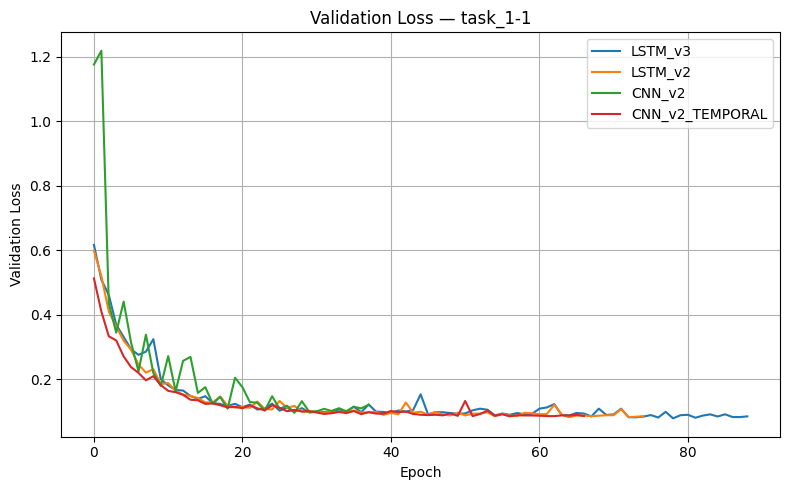


📈 Plotting task_1-2
  Adding LSTM_v3 (len=51)
    ↳ min val_loss = 0.003013 at epoch 40
  Adding LSTM_v2 (len=51)
    ↳ min val_loss = 0.002917 at epoch 40
  Adding CNN_v2 (len=67)
    ↳ min val_loss = 0.002458 at epoch 56
  Adding CNN_v2_TEMPORAL (len=70)
    ↳ min val_loss = 0.002296 at epoch 59

🏆 BEST for task_1-2:
   Model: CNN_v2_TEMPORAL
   Val Loss: 0.002296
   Epoch: 59


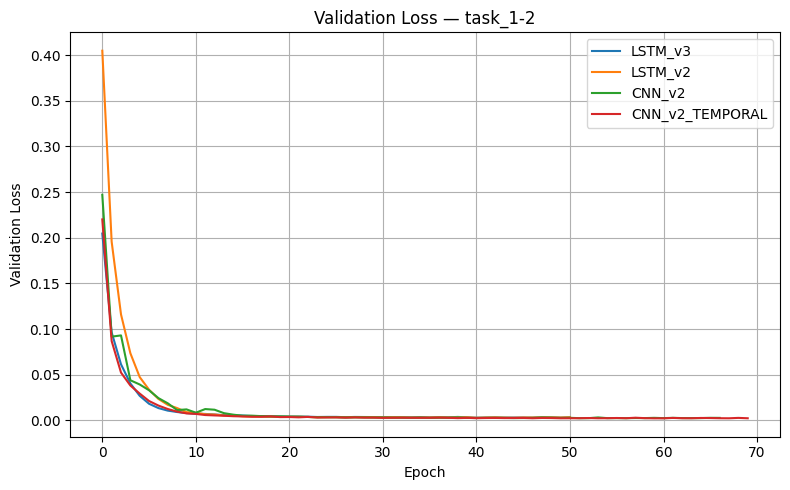


📈 Plotting task_1-3
  Adding LSTM_v3 (len=50)
    ↳ min val_loss = 0.088960 at epoch 39
  Adding LSTM_v2 (len=50)
    ↳ min val_loss = 0.090455 at epoch 39
  Adding CNN_v2 (len=50)
    ↳ min val_loss = 0.079711 at epoch 39
  Adding CNN_v2_TEMPORAL (len=78)
    ↳ min val_loss = 0.025034 at epoch 67

🏆 BEST for task_1-3:
   Model: CNN_v2_TEMPORAL
   Val Loss: 0.025034
   Epoch: 67


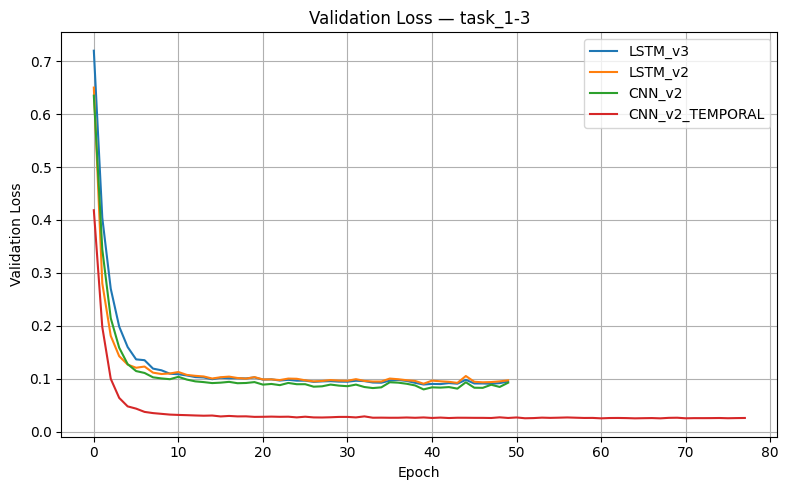


📈 Plotting task_2-1
  Adding LSTM_v3 (len=72)
    ↳ min val_loss = 0.080891 at epoch 61
  Adding LSTM_v2 (len=49)
    ↳ min val_loss = 0.091055 at epoch 38
  Adding CNN_v2 (len=35)
    ↳ min val_loss = 0.121353 at epoch 24
  Adding CNN_v2_TEMPORAL (len=63)
    ↳ min val_loss = 0.104467 at epoch 52

🏆 BEST for task_2-1:
   Model: LSTM_v3
   Val Loss: 0.080891
   Epoch: 61


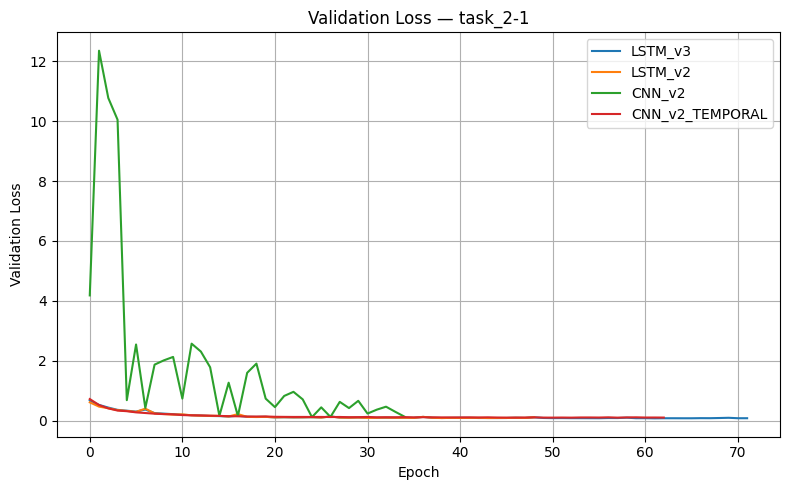


📈 Plotting task_2-2
  Adding LSTM_v3 (len=83)
    ↳ min val_loss = 0.003085 at epoch 72
  Adding LSTM_v2 (len=66)
    ↳ min val_loss = 0.003129 at epoch 55
  Adding CNN_v2 (len=44)
    ↳ min val_loss = 0.004263 at epoch 33
  Adding CNN_v2_TEMPORAL (len=88)
    ↳ min val_loss = 0.003135 at epoch 77

🏆 BEST for task_2-2:
   Model: LSTM_v3
   Val Loss: 0.003085
   Epoch: 72


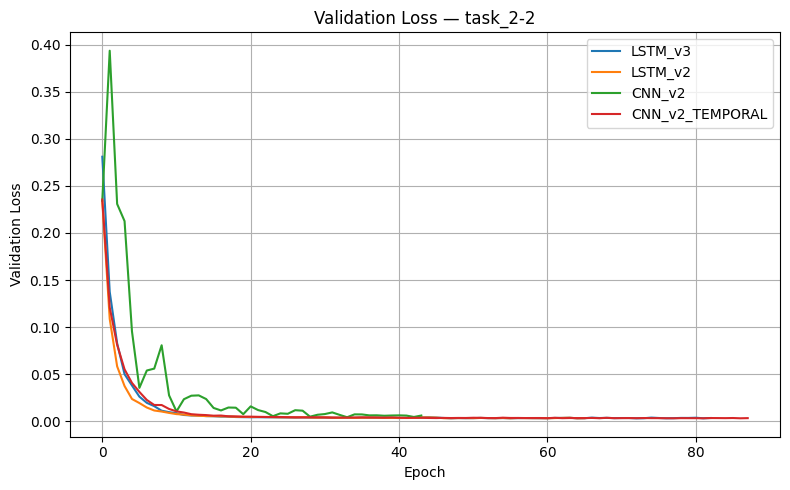


📈 Plotting task_2-3
  Adding LSTM_v3 (len=51)
    ↳ min val_loss = 0.039080 at epoch 40
  Adding LSTM_v2 (len=51)
    ↳ min val_loss = 0.039062 at epoch 40
  Adding CNN_v2 (len=38)
    ↳ min val_loss = 0.044928 at epoch 27
  Adding CNN_v2_TEMPORAL (len=81)
    ↳ min val_loss = 0.021176 at epoch 70

🏆 BEST for task_2-3:
   Model: CNN_v2_TEMPORAL
   Val Loss: 0.021176
   Epoch: 70


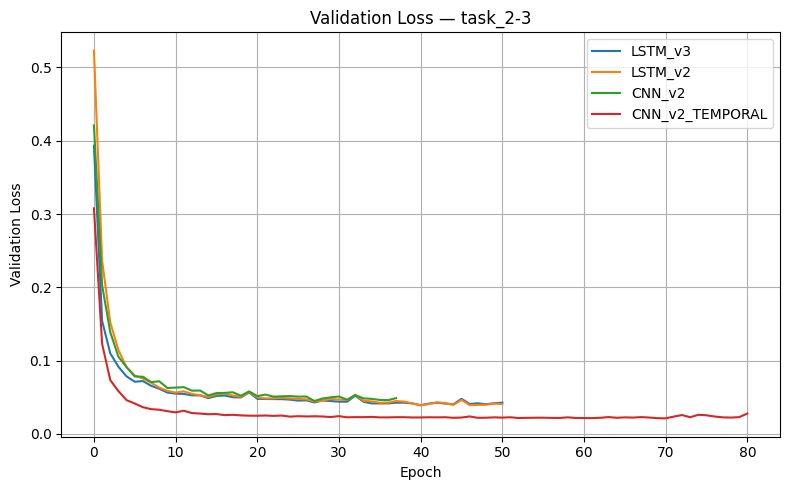


📈 Plotting task_3-1
  Adding LSTM_v3 (len=101)
    ↳ min val_loss = 0.163241 at epoch 90
  Adding LSTM_v2 (len=104)
    ↳ min val_loss = 0.163215 at epoch 93
  Adding CNN_v2 (len=225)
    ↳ min val_loss = 0.161675 at epoch 214
  Adding CNN_v2_TEMPORAL (len=127)
    ↳ min val_loss = 0.158933 at epoch 116

🏆 BEST for task_3-1:
   Model: CNN_v2_TEMPORAL
   Val Loss: 0.158933
   Epoch: 116


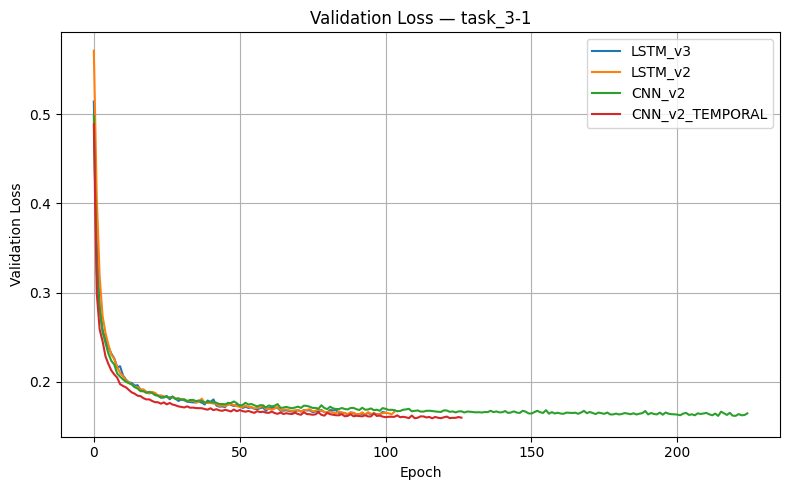


📈 Plotting task_3-2
  Adding LSTM_v3 (len=104)
    ↳ min val_loss = 0.146229 at epoch 93
  Adding LSTM_v2 (len=104)
    ↳ min val_loss = 0.150984 at epoch 93
  Adding CNN_v2 (len=62)
    ↳ min val_loss = 0.152862 at epoch 51
  Adding CNN_v2_TEMPORAL (len=77)
    ↳ min val_loss = 0.223576 at epoch 66

🏆 BEST for task_3-2:
   Model: LSTM_v3
   Val Loss: 0.146229
   Epoch: 93


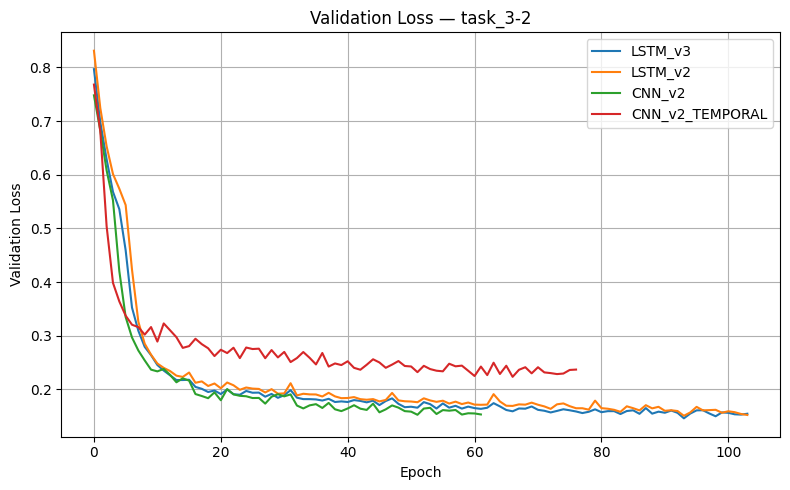


📈 Plotting task_3-3
  Adding LSTM_v3 (len=36)
    ↳ min val_loss = 0.152591 at epoch 25
  Adding LSTM_v2 (len=24)
    ↳ min val_loss = 0.184320 at epoch 13
  Adding CNN_v2 (len=17)
    ↳ min val_loss = 0.280918 at epoch 6
  Adding CNN_v2_TEMPORAL (len=16)
    ↳ min val_loss = 0.313505 at epoch 5

🏆 BEST for task_3-3:
   Model: LSTM_v3
   Val Loss: 0.152591
   Epoch: 25


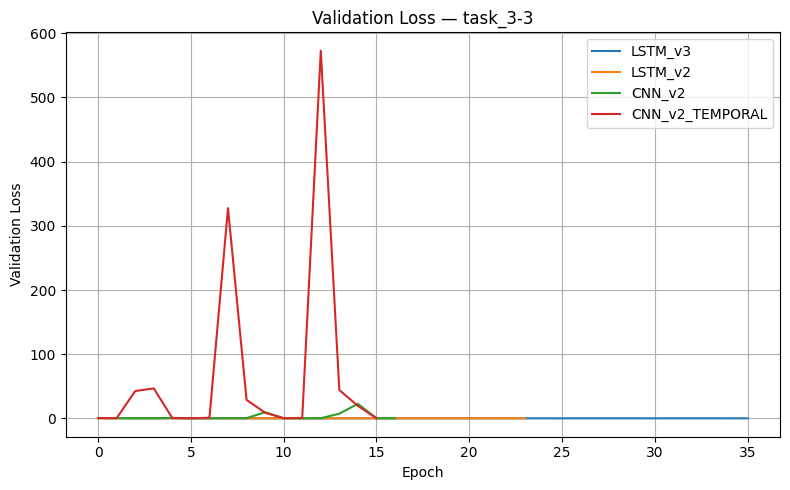


📈 Plotting task_4-1
  Adding LSTM_v3 (len=41)
    ↳ min val_loss = 0.084743 at epoch 36
  Adding LSTM_v2 (len=47)
    ↳ min val_loss = 0.085163 at epoch 36
  Adding CNN_v2 (len=77)
    ↳ min val_loss = 0.094990 at epoch 66
  Adding CNN_v2_TEMPORAL (len=36)
    ↳ min val_loss = 0.329874 at epoch 25

🏆 BEST for task_4-1:
   Model: LSTM_v3
   Val Loss: 0.084743
   Epoch: 36


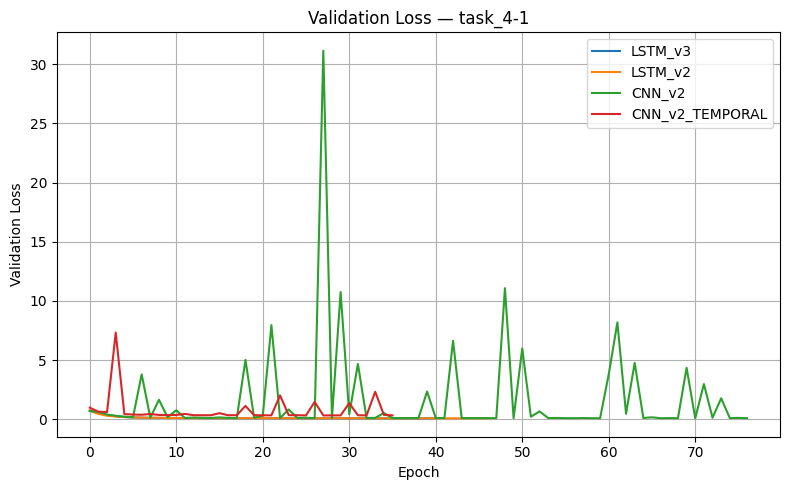


📈 Plotting task_4-2
  Adding LSTM_v3 (len=40)
    ↳ min val_loss = 0.085398 at epoch 36
  Adding LSTM_v2 (len=47)
    ↳ min val_loss = 0.084688 at epoch 36
  Adding CNN_v2 (len=47)
    ↳ min val_loss = 0.099687 at epoch 36
  Adding CNN_v2_TEMPORAL (len=46)
    ↳ min val_loss = 0.324872 at epoch 35

🏆 BEST for task_4-2:
   Model: LSTM_v2
   Val Loss: 0.084688
   Epoch: 36


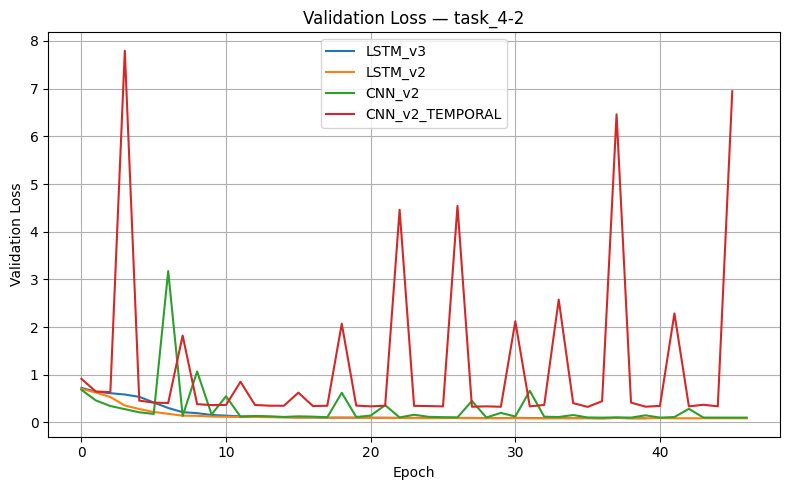


📈 Plotting task_4-3
  Adding LSTM_v3 (len=52)
    ↳ min val_loss = 0.022695 at epoch 51
  Adding LSTM_v2 (len=53)
    ↳ min val_loss = 0.024125 at epoch 42
  Adding CNN_v2 (len=66)
    ↳ min val_loss = 0.032440 at epoch 55
  Adding CNN_v2_TEMPORAL (len=32)
    ↳ min val_loss = 0.045039 at epoch 21

🏆 BEST for task_4-3:
   Model: LSTM_v3
   Val Loss: 0.022695
   Epoch: 51


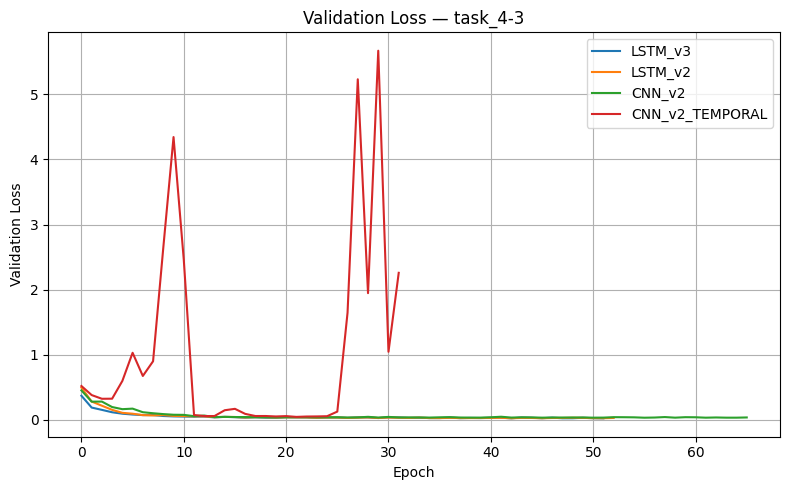


📈 Plotting task_4-4
  Adding LSTM_v3 (len=48)
    ↳ min val_loss = 0.125147 at epoch 43
  Adding LSTM_v2 (len=55)
    ↳ min val_loss = 0.125688 at epoch 44
  Adding CNN_v2 (len=54)
    ↳ min val_loss = 0.212387 at epoch 43
  Adding CNN_v2_TEMPORAL (len=37)
    ↳ min val_loss = 0.279017 at epoch 26

🏆 BEST for task_4-4:
   Model: LSTM_v3
   Val Loss: 0.125147
   Epoch: 43


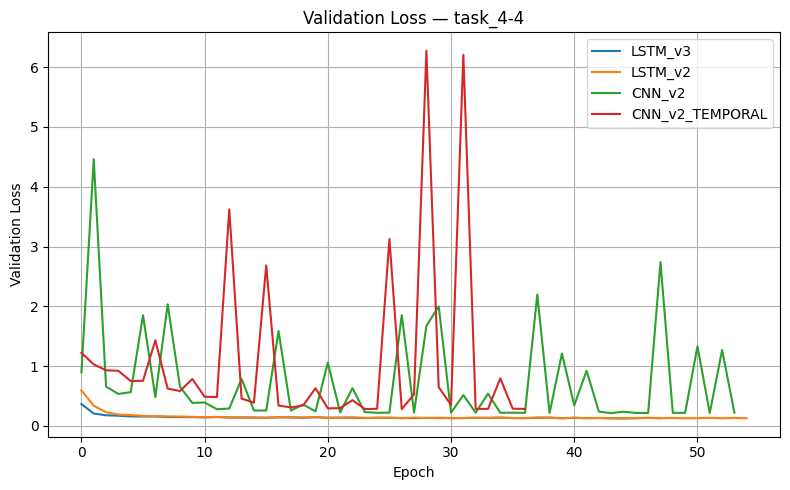


📈 Plotting task_4-5
  Adding LSTM_v3 (len=30)
    ↳ min val_loss = 0.954949 at epoch 29
  Adding LSTM_v2 (len=88)
    ↳ min val_loss = 0.948890 at epoch 77
  Adding CNN_v2 (len=27)
    ↳ min val_loss = 0.969683 at epoch 16
  Adding CNN_v2_TEMPORAL (len=25)
    ↳ min val_loss = 0.629126 at epoch 14

🏆 BEST for task_4-5:
   Model: CNN_v2_TEMPORAL
   Val Loss: 0.629126
   Epoch: 14


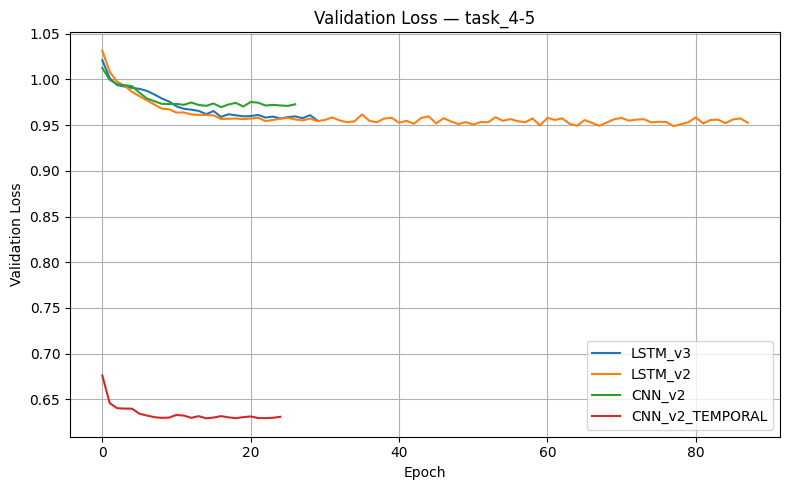

In [9]:
import torch
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np

# --- CONFIG ---
base_dir = Path("/home/ir-rous1/rds/rds-ukaea-ap002-mOlK9qn0PlQ/ir-rous1/output")

runs = {
    "LSTM_v3": "cnn-baseline/output_LSTM_v3_with_sparsity",
    "LSTM_v2": "cnn-baseline/output_LSTM_v2_with_sparsity",
    "CNN_v2":  "cnn-baseline/output_CNN_v2_with_sparsity",
    "CNN_v2_TEMPORAL":  "cnn-baseline/output_CNN_v2_TEMPORAL_with_sparsity",
}

seed = "seed_23"

print("Base dir exists:", base_dir.exists())
print("--------------------------------------------------")

# --- COLLECT DATA ---
task_data = {}

for model_name, rel_path in runs.items():
    run_path = base_dir / rel_path

    print(f"\n🔍 Checking model: {model_name}")
    print(f"Path: {run_path}")
    print("Exists:", run_path.exists())

    if not run_path.exists():
        print("❌ Path does not exist, skipping")
        continue

    history_files = list(run_path.rglob("training_history.pt"))
    print(f"📂 Found {len(history_files)} training_history.pt files")

    for history_path in history_files:
        print(f"\n➡️ Loading: {history_path}")

        try:
            history = torch.load(history_path, map_location="cpu")
        except Exception as e:
            print("❌ Failed to load:", e)
            continue

        if "val_loss" not in history:
            print("❌ No val_loss key, skipping")
            continue

        val_loss = history["val_loss"]

        # Convert to numpy (safe)
        val_loss = np.array(val_loss)

        print(f"val_loss length: {len(val_loss)}")

        # Extract task name
        task_name = next(
            (p for p in history_path.parts if p.startswith("task_")),
            "unknown_task"
        )

        print(f"Assigned task: {task_name}")

        task_data.setdefault(task_name, {})
        task_data[task_name][model_name] = val_loss

print("\n==================================================")
print("📊 FINAL COLLECTED TASKS:")
for k, v in task_data.items():
    print(f"{k}: models -> {list(v.keys())}")
print("==================================================")

# --- ANALYSIS + PLOTTING ---

if not task_data:
    print("❌ No data collected. Check paths above.")
else:
    for task_name, models in sorted(task_data.items()):
        print(f"\n📈 Plotting {task_name}")

        plt.figure(figsize=(8, 5))

        best_model = None
        best_loss = float("inf")
        best_epoch = -1

        for model_name, val_loss in models.items():
            print(f"  Adding {model_name} (len={len(val_loss)})")

            plt.plot(val_loss, label=model_name)

            # --- compute best ---
            min_idx = int(np.argmin(val_loss))
            min_val = float(val_loss[min_idx])

            print(f"    ↳ min val_loss = {min_val:.6f} at epoch {min_idx}")

            if min_val < best_loss:
                best_loss = min_val
                best_model = model_name
                best_epoch = min_idx

        # --- print best model for this task ---
        print(f"\n🏆 BEST for {task_name}:")
        print(f"   Model: {best_model}")
        print(f"   Val Loss: {best_loss:.6f}")
        print(f"   Epoch: {best_epoch}")

        # --- plot formatting ---
        plt.title(f"Validation Loss — {task_name}")
        plt.xlabel("Epoch")
        plt.ylabel("Validation Loss")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()

        plt.show()

In [4]:
# import pandas as pd
# from pathlib import Path

# base_dir = Path("/home/ir-rous1/rds/rds-ukaea-ap002-mOlK9qn0PlQ/ir-rous1/sparse_temporal_temp/tokamark_baseline/tokamark/output")

# tasks = [
#     "task_1-1","task_1-2","task_1-3",
#     "task_2-1","task_2-2","task_2-3",
#     "task_3-1","task_3-2","task_3-3",
#     "task_4-1","task_4-2","task_4-3","task_4-4","task_4-5"
# ]

# rows = []

# for task in tasks:
#     # adjust path depending on where metrics actually live
#     csv_path = base_dir / "mean" / "random" / task / "task_metrics.csv"
    
#     if csv_path.exists():
#         df = pd.read_csv(csv_path)       
#         row = df[df["feature_name"] == task]
#         if not row.empty:
#             rows.append(row.iloc[0])

# result = pd.DataFrame(rows)
# print(result)
# result.to_csv("combined_task_metrics.csv", index=False)

import pandas as pd
from pathlib import Path

base_dir = Path("/home/ir-rous1/rds/rds-ukaea-ap002-mOlK9qn0PlQ/ir-rous1/sparse_temporal_temp/tokamark_baseline/tokamark/output")

tasks = [
    "task_1-1","task_1-2","task_1-3",
    "task_2-1","task_2-2","task_2-3",
    "task_3-1","task_3-2","task_3-3",
    "task_4-1","task_4-2","task_4-3","task_4-4","task_4-5"
]

rows = []

for task in tasks:
    csv_path = base_dir / "mean" / "temporal" / task / "task_metrics.csv"
    
    if csv_path.exists():
        df = pd.read_csv(csv_path)
        row = df[df["feature_name"] == task]
        
        if not row.empty:
            rows.append({
                "task": task,
                "n_shots": row.iloc[0]["n_shots"],
                "NRMSE": row.iloc[0]["NRMSE_mean"]
            })

result = pd.DataFrame(rows)
print(result)

        task  n_shots     NRMSE
0   task_1-1   2712.0  0.879299
1   task_1-2   2734.0  1.000271
2   task_1-3   2738.0  0.950906
3   task_2-1   2714.0  0.896576
4   task_2-2   2734.0  0.992351
5   task_2-3   2738.0  0.928918
6   task_3-1   2003.0  0.968612
7   task_3-2   2888.0  0.770124
8   task_3-3   1986.0  0.985860
9   task_4-1   2886.0  0.692759
10  task_4-2   2886.0  0.692759
11  task_4-3   2687.0  0.863272
12  task_4-4   3106.0  0.923939
13  task_4-5   3003.0  0.819640


In [ ]:
===== TASK TABLE =====

   feature_name  n_shots  NRMSE_mean
0      task_1-1     1020      0.2209
1      task_1-2     1031      0.0496
3      task_1-3     1034      0.1512
8      task_2-1     1020      0.2798
5      task_2-2     1031      0.0587
6      task_2-3     1034      0.1326
7      task_3-1      885      0.3835
2      task_3-2     1060      0.3063
10     task_3-3      872      0.3316
4      task_4-3      992      0.1107
9      task_4-4     1106      0.3743

In [3]:
import pandas as pd
from pathlib import Path

base_dir = Path("/home/ir-rous1/rds/rds-ukaea-ap002-mOlK9qn0PlQ/ir-rous1/sparse_temporal_temp/tokamark_baseline/tokamark/output")

tasks = [
    "task_1-1","task_1-2","task_1-3",
    "task_2-1","task_2-2","task_2-3",
    "task_3-1","task_3-2","task_3-3",
    "task_4-1","task_4-2","task_4-3","task_4-4","task_4-5"
]

rows = []

for task in tasks:
    csv_path = base_dir / "persistence" / "temporal" / task / "task_metrics.csv"
    
    if csv_path.exists():
        df = pd.read_csv(csv_path)
        row = df[df["feature_name"] == task]
        
        if not row.empty:
            rows.append({
                "task": task,
                "n_shots": row.iloc[0]["n_shots"],
                "NRMSE": row.iloc[0]["NRMSE_mean"]
            })

result = pd.DataFrame(rows)
print(result)

       task  n_shots     NRMSE
0  task_3-1   2004.0  0.535207
1  task_3-2   2889.0  0.268482
2  task_4-1   2861.0  0.159708
3  task_4-2   2861.0  0.159708
4  task_4-4   3107.0  0.638999
5  task_4-5   3004.0  1.023496


In [21]:
import pandas as pd
from pathlib import Path

base = Path("/home/ir-rous1/rds/rds-ukaea-ap002-mOlK9qn0PlQ/ir-rous1/output/cnn-baseline/results")

tasks = [
    "task_1-1","task_1-2","task_1-3",
    "task_2-1","task_2-2","task_2-3",
    "task_3-1","task_3-2","task_3-3",
    "task_4-1","task_4-2","task_4-3","task_4-4","task_4-5"
]

models = {
    "cnn_random": ("random", "cnn"),
    "lstm_random": ("random", "lstm"),
    "cnn_temporal": ("temporal", "cnn"),
    "lstm_temporal": ("temporal", "lstm"),
    }

rows = []

for task in tasks:
    row = {"task": task}
    
    for model_name, (setting, model) in models.items():
        path = base / setting / model / "seed_23" / task / "task_metrics.csv"
        
        if path.exists():
            df = pd.read_csv(path)
            match = df[df["feature_name"] == task]
            
            if not match.empty:
                row[model_name] = float(match.iloc[0]["NRMSE_mean"])
            else:
                row[model_name] = None
        else:
            row[model_name] = None

    rows.append(row)

result = pd.DataFrame(rows)

print(result)

# optional save
result.to_csv("rmse_all_models_tasks.csv", index=False)

        task  cnn_random  lstm_random  cnn_temporal  lstm_temporal
0   task_1-1    0.209122     0.221508      0.619178       0.623190
1   task_1-2    0.047335     0.051011      0.134854       0.125398
2   task_1-3    0.148079     0.159098      0.501589       0.256718
3   task_2-1    0.275094     0.219743      1.756950       0.559740
4   task_2-2    0.066222     0.056771      0.133924       0.125101
5   task_2-3    0.135790     0.126259      0.229588       0.193725
6   task_3-1    0.396215     0.374334      0.380708       0.358136
7   task_3-2    0.330850     0.335321      0.910981       0.927532
8   task_3-3    0.385904     0.318705      0.752042       1.471762
9   task_4-1    0.275089     0.227441      1.097002       1.178805
10  task_4-2    0.273650     0.228596      3.060325            NaN
11  task_4-3    0.129125     0.117939      1.324902       0.819838
12  task_4-4    0.529914     0.403943      0.578564       0.495393
13  task_4-5    0.650670     0.648798      1.017884       0.73

In [24]:
data.keys()

dict_keys(['step', 'train_loss', 'val_loss', 'lr'])

In [30]:
import torch
import pandas as pd
from pathlib import Path

# -----------------------------
# CONFIG
# -----------------------------
base = Path("/home/ir-rous1/rds/rds-ukaea-ap002-mOlK9qn0PlQ/ir-rous1/output/cnn-baseline/output")

tasks = [
    "task_1-1","task_1-2","task_1-3",
    "task_2-1","task_2-2","task_2-3",
    "task_3-1","task_3-2","task_3-3",
    "task_4-1","task_4-2","task_4-3","task_4-4","task_4-5"
]

models = {
    "cnn_random": ("random", "cnn"),
    "lstm_random": ("random", "lstm"),
    "cnn_temporal": ("temporal", "cnn"),
    "lstm_temporal": ("temporal", "lstm"),
}

# -----------------------------
# LOAD ALL DATA
# -----------------------------
data_store = {}

for task in tasks:
    data_store[task] = {}

    for model_name, (setting, model) in models.items():
        path = base / setting / model / task / "seed_23" / "first_epoch_stats.pt"

        if path.exists():
            d = torch.load(path, map_location="cpu")

            data_store[task][model_name] = {
                "train": {
                    "samples": d.get("train_samples"),
                    "unique_shots": d.get("train_unique_shots"),
                },
                "val": {
                    "samples": d.get("val_samples"),
                    "unique_shots": d.get("val_unique_shots"),
                },
            }
        else:
            data_store[task][model_name] = {
                "train": {"samples": None, "unique_shots": None},
                "val": {"samples": None, "unique_shots": None},
            }

# -----------------------------
# BUILD DATAFRAME FUNCTION
# -----------------------------
def build_df(split):
    rows = []

    for task in tasks:
        row = {"task": task}

        for model_name in models.keys():
            samples = data_store[task][model_name][split]["samples"]
            unique = data_store[task][model_name][split]["unique_shots"]

            # store as tuple (clean + compact)
            row[model_name] = (samples, unique)

        rows.append(row)

    return pd.DataFrame(rows)

# -----------------------------
# FINAL DATAFRAMES
# -----------------------------
train_df = build_df("train")
val_df = build_df("val")

# -----------------------------
# OUTPUT
# -----------------------------
print("===== TRAIN =====")
print(train_df)

print("\n===== VAL =====")
print(val_df)

# Optional save
train_df.to_csv("train_first_epoch_stats.csv", index=False)
val_df.to_csv("val_first_epoch_stats.csv", index=False)

===== TRAIN =====
        task      cnn_random     lstm_random    cnn_temporal   lstm_temporal
0   task_1-1  (458240, 8257)  (458240, 8257)  (334848, 6127)  (334848, 6127)
1   task_1-2  (580608, 8382)  (580608, 8382)  (428032, 6237)  (428032, 6237)
2   task_1-3  (653312, 8403)  (653312, 8403)  (462336, 6257)  (462336, 6257)
3   task_2-1  (506368, 8268)  (506368, 8268)  (371200, 6137)  (371200, 6137)
4   task_2-2  (588288, 8382)  (588288, 8382)  (431616, 6237)  (431616, 6237)
5   task_2-3  (668672, 8403)  (668672, 8403)  (471040, 6257)  (471040, 6257)
6   task_3-1  (539648, 7226)  (539648, 7226)  (409600, 5641)  (409600, 5641)
7   task_3-2  (818176, 8531)  (818176, 8531)  (573952, 6271)  (573952, 6271)
8   task_3-3   (86528, 7072)   (86528, 7072)   (64000, 5507)   (64000, 5507)
9   task_4-1  (107520, 8513)  (107520, 8513)   (69632, 6261)   (69632, 6261)
10  task_4-2  (107520, 8513)  (107520, 8513)   (69632, 6261)   (69632, 6261)
11  task_4-3   (73728, 8062)   (73728, 8062)   (49152, 595

In [31]:
import torch
import pandas as pd
from pathlib import Path

# -----------------------------
# CONFIG
# -----------------------------
base = Path("/home/ir-rous1/rds/rds-ukaea-ap002-mOlK9qn0PlQ/ir-rous1/output/cnn-baseline/output")

tasks = [
    "task_1-1","task_1-2","task_1-3",
    "task_2-1","task_2-2","task_2-3",
    "task_3-1","task_3-2","task_3-3",
    "task_4-1","task_4-2","task_4-3","task_4-4","task_4-5"
]

models = {
    "cnn_random": ("random", "cnn"),
    "lstm_random": ("random", "lstm"),
    "cnn_temporal": ("temporal", "cnn"),
    "lstm_temporal": ("temporal", "lstm"),
}

# -----------------------------
# LOAD DATA
# -----------------------------
data_store = {}

for task in tasks:
    data_store[task] = {}

    for model_name, (setting, model) in models.items():
        path = base / setting / model / task / "seed_23" / "first_epoch_stats.pt"

        if path.exists():
            d = torch.load(path, map_location="cpu")

            data_store[task][model_name] = {
                "train": (d.get("train_samples"), d.get("train_unique_shots")),
                "val": (d.get("val_samples"), d.get("val_unique_shots")),
            }
        else:
            data_store[task][model_name] = {
                "train": (None, None),
                "val": (None, None),
            }

# -----------------------------
# BUILD COMPARISON DF
# -----------------------------
def build_df(split):
    rows = []

    for task in tasks:
        row = {"task": task}

        # store model values
        for model_name in models.keys():
            row[model_name] = data_store[task][model_name][split]

        # model-to-model comparisons
        row["cnn_random_vs_lstm_random"] = (
            data_store[task]["cnn_random"][split]
            == data_store[task]["lstm_random"][split]
        )

        row["cnn_temporal_vs_lstm_temporal"] = (
            data_store[task]["cnn_temporal"][split]
            == data_store[task]["lstm_temporal"][split]
        )

        row["cnn_random_vs_cnn_temporal"] = (
            data_store[task]["cnn_random"][split]
            == data_store[task]["cnn_temporal"][split]
        )

        row["lstm_random_vs_lstm_temporal"] = (
            data_store[task]["lstm_random"][split]
            == data_store[task]["lstm_temporal"][split]
        )

        rows.append(row)

    return pd.DataFrame(rows)

# -----------------------------
# FINAL DATAFRAMES
# -----------------------------
train_df = build_df("train")
val_df = build_df("val")

# -----------------------------
# OUTPUT
# -----------------------------
print("===== TRAIN =====")
print(train_df)

print("\n===== VAL =====")
print(val_df)

# Optional save
train_df.to_csv("train_model_comparison.csv", index=False)
val_df.to_csv("val_model_comparison.csv", index=False)

===== TRAIN =====
        task      cnn_random     lstm_random    cnn_temporal   lstm_temporal  \
0   task_1-1  (458240, 8257)  (458240, 8257)  (334848, 6127)  (334848, 6127)   
1   task_1-2  (580608, 8382)  (580608, 8382)  (428032, 6237)  (428032, 6237)   
2   task_1-3  (653312, 8403)  (653312, 8403)  (462336, 6257)  (462336, 6257)   
3   task_2-1  (506368, 8268)  (506368, 8268)  (371200, 6137)  (371200, 6137)   
4   task_2-2  (588288, 8382)  (588288, 8382)  (431616, 6237)  (431616, 6237)   
5   task_2-3  (668672, 8403)  (668672, 8403)  (471040, 6257)  (471040, 6257)   
6   task_3-1  (539648, 7226)  (539648, 7226)  (409600, 5641)  (409600, 5641)   
7   task_3-2  (818176, 8531)  (818176, 8531)  (573952, 6271)  (573952, 6271)   
8   task_3-3   (86528, 7072)   (86528, 7072)   (64000, 5507)   (64000, 5507)   
9   task_4-1  (107520, 8513)  (107520, 8513)   (69632, 6261)   (69632, 6261)   
10  task_4-2  (107520, 8513)  (107520, 8513)   (69632, 6261)   (69632, 6261)   
11  task_4-3   (73728,